# Movie Success Prediction
## Notebook 03 — Statistical Correlation Analysis
**Dataset:** `movies_cleaned.xlsx` — 5,475 movies · 20 columns · 1980–2020

---

## STEP 1 — Install & Import Libraries

In [ ]:
# Install openpyxl if needed (required to read .xlsx in Colab)
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import (pearsonr, spearmanr, pointbiserialr,
                          mannwhitneyu, kruskal, chi2_contingency)
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

print('Libraries ready')

Libraries ready


## STEP 2 — Preprocessing for Analysis
We engineer a few extra columns and create a **binary hit flag** for point-biserial and hypothesis tests.


Please explain this

In [ ]:
df2 = df.copy()

# ── Log-transform skewed columns (budget, gross, votes are heavily right-skewed)
df2['log_budget'] = np.log1p(df2['budget'])
df2['log_gross']  = np.log1p(df2['gross'])
df2['log_votes']  = np.log1p(df2['votes'])
df2['log_roi']    = np.log1p(df2['roi'].clip(lower=0))

# ── Profit
df2['profit'] = df2['gross'] - df2['budget']

# ── Decade
df2['decade'] = (df2['year'] // 10 * 10).astype(str) + 's'

# ── Binary hit: blockbuster OR hit in roi_class
df2['is_hit'] = df2['roi_class'].isin(['hit', 'blockbuster']).astype(int)

# ── Clean rating: keep 4 main categories
df2['rating_clean'] = df2['rating'].where(
    df2['rating'].isin(['G','PG','PG-13','R']), 'Other')

# ── Encode roi_class as ordered integer for correlation
roi_order = {'flop': 0, 'below_avg': 1, 'hit': 2, 'blockbuster': 3}
df2['roi_class_num'] = df2['roi_class'].map(roi_order)

hit_rate = df2['is_hit'].mean() * 100
print(f'Rows           : {len(df2)}')
print(f'Hit rate       : {hit_rate:.1f}%  ({df2["is_hit"].sum()} hits out of {len(df2)})')
print(f'Log columns added: log_budget, log_gross, log_votes, log_roi')
print(f'New columns    : profit, decade, is_hit, rating_clean, roi_class_num')

Rows           : 5475
Hit rate       : 55.2%  (3022 hits out of 5475)
Log columns added: log_budget, log_gross, log_votes, log_roi
New columns    : profit, decade, is_hit, rating_clean, roi_class_num


## STEP 7 — Score vs Votes: Quality vs Popularity

This analysis helps understand whether audience appreciation and engagement contribute indirectly to movie success.

studies the relationship between IMDb movie ratings (score) and audience engagement (votes) using Spearman correlation.

Why is it used?

It helps understand whether better-rated movies also attract higher audience popularity and engagement.

What are we doing?

We compare movie scores with vote counts and visualize:

score vs popularity relationship,
and score distribution for hits vs flops.

Score vs Votes — Spearman r = 0.4871  p = 0.00e+00


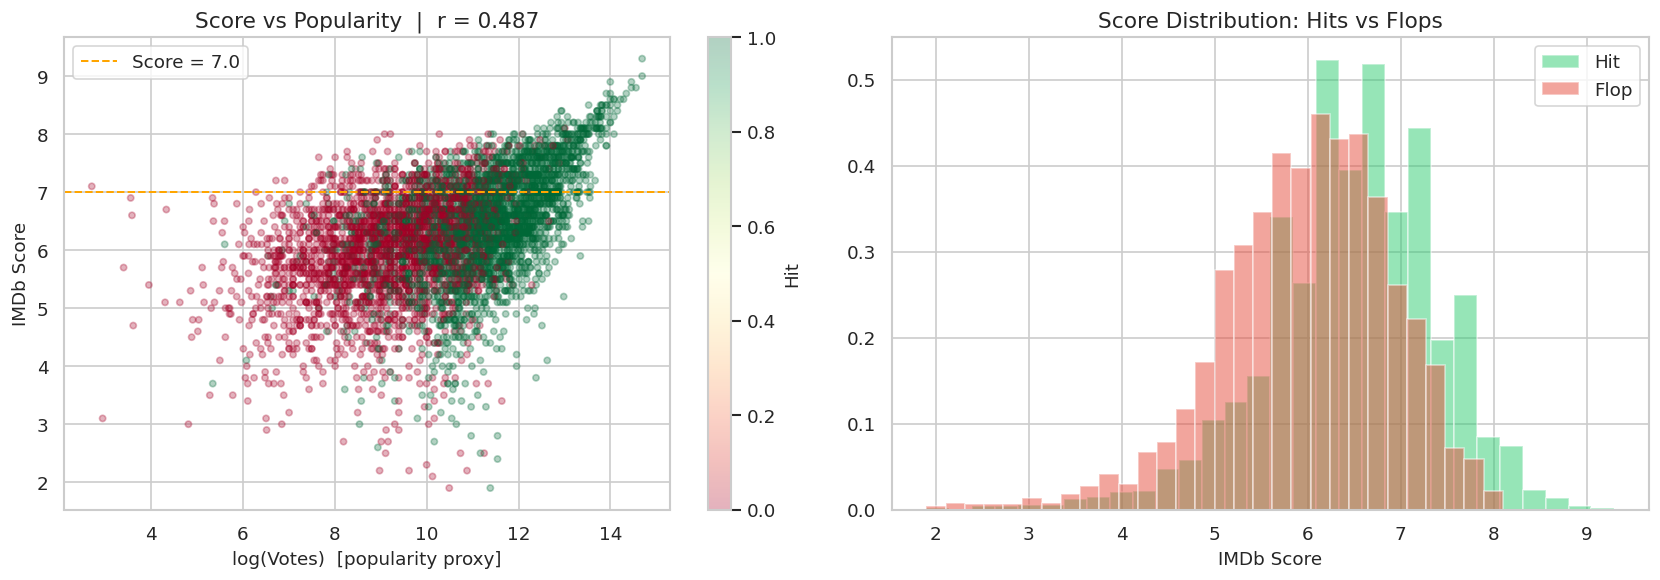

In [ ]:
sv = df2[['score','votes','log_votes','is_hit']].dropna()

r_s, p_s = spearmanr(sv['score'], sv['votes'])
print(f'Score vs Votes — Spearman r = {r_s:.4f}  p = {p_s:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: log_votes vs score, colored by hit
sc = axes[0].scatter(sv['log_votes'], sv['score'],
                     c=sv['is_hit'], cmap='RdYlGn', alpha=0.3, s=14)
axes[0].axhline(7.0, color='orange', linestyle='--', lw=1.2, label='Score = 7.0')
axes[0].set_xlabel('log(Votes)  [popularity proxy]')
axes[0].set_ylabel('IMDb Score')
axes[0].set_title(f'Score vs Popularity  |  r = {r_s:.3f}')
axes[0].legend(); plt.colorbar(sc, ax=axes[0], label='Hit')

# KDE by hit status
for label, grp, color in [('Hit', sv[sv['is_hit']==1], '#2ecc71'),
                           ('Flop', sv[sv['is_hit']==0], '#e74c3c')]:
    axes[1].hist(grp['score'], bins=30, alpha=0.5, color=color,
                 density=True, label=label, edgecolor='white')
axes[1].set_xlabel('IMDb Score')
axes[1].set_title('Score Distribution: Hits vs Flops')
axes[1].legend()

plt.tight_layout()
plt.savefig('score_vs_votes.png', bbox_inches='tight')
plt.show()

#Interpretation of Outputs
Spearman r = 0.487: Movies with higher ratings generally receive more audience engagement.

Scatterplot: Most hit movies cluster in the higher score and higher popularity region.

Histogram Distribution: Hit movies are concentrated around higher IMDb scores, while flops are more common at lower score ranges.

Score = 7 Reference Line: Movies above IMDb score 7 are more frequently associated with successful movies.
#Overall Insight

Audience appreciation and popularity show a moderate positive relationship, and successful movies generally tend to receive higher ratings and engagement.

## STEP 8 — Point-Biserial Correlation

**Point-biserial** is the correct method when one variable is **binary** (is_hit: 0 or 1) and the other is continuous. It tells us which numeric features best separate hits from flops.


Measures the relationship between a binary variable (is_hit) and continuous numerical variables.

Why is it used?

It helps identify which numerical features best separate hit movies from flop movies.

What are we doing?

We calculate the correlation between movie success (is_hit) and features like votes, budget, gross revenue, score, ROI, and runtime.

=== Point-Biserial Correlation with is_hit ===
      Feature  Point-Biserial r   p-value Significant
      log_roi            0.6831  0.00e+00           ✅
    log_gross            0.6515  0.00e+00           ✅
    log_votes            0.6010  0.00e+00           ✅
        gross            0.3842 1.11e-188           ✅
        votes            0.3827 2.10e-190           ✅
         year            0.2635  1.29e-87           ✅
        score            0.2486  6.99e-78           ✅
       budget            0.1891  1.70e-36           ✅
      runtime            0.1448  4.95e-27           ✅
   log_budget            0.1307  3.82e-18           ✅
release_month            0.0409  2.47e-03           ✅
          roi            0.0224  1.41e-01           ❌


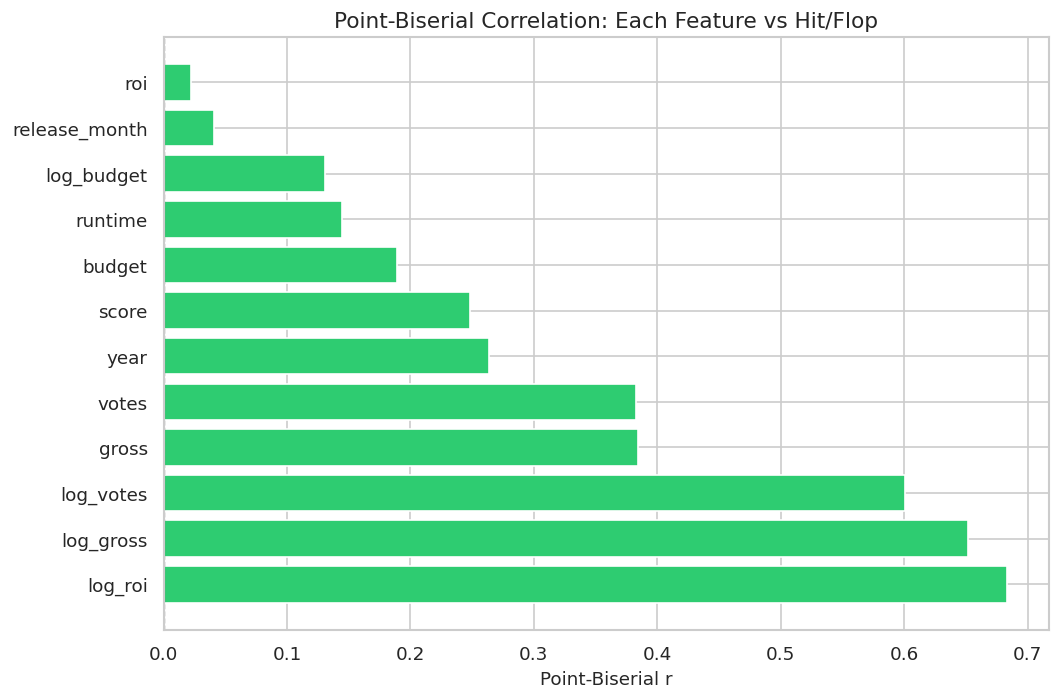

In [ ]:
continuous_features = ['score','votes','budget','gross','runtime',
                       'log_budget','log_gross','log_votes','roi','log_roi',
                       'release_month','year']

results = []
for feat in continuous_features:
    tmp = df2[['is_hit', feat]].dropna()
    r, p = pointbiserialr(tmp['is_hit'], tmp[feat])
    results.append({'Feature': feat, 'Point-Biserial r': round(r, 4),
                    'p-value': p, 'Significant': '✅' if p < 0.05 else '❌'})

pb_df = pd.DataFrame(results).sort_values('Point-Biserial r', ascending=False)
pb_df['p-value'] = pb_df['p-value'].apply(lambda x: f'{x:.2e}')

print('=== Point-Biserial Correlation with is_hit ===')
print(pb_df.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in pb_df['Point-Biserial r']]
ax.barh(pb_df['Feature'], pb_df['Point-Biserial r'], color=colors)
ax.axvline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xlabel('Point-Biserial r')
ax.set_title('Point-Biserial Correlation: Each Feature vs Hit/Flop')
plt.tight_layout()
plt.savefig('point_biserial.png', bbox_inches='tight')
plt.show()

#Interpretation of Outputs
log_roi (r = 0.683): ROI has a very strong relationship with movie success.

log_gross (r = 0.652): Higher revenue movies are more likely to be hits.

log_votes (r = 0.601): Audience engagement strongly relates to movie success.

Score (r = 0.249): Better-rated movies are moderately more likely to succeed.

Release Month (r = 0.041): Release timing has very little influence on success.

ROI (p > 0.05): Raw ROI is not statistically significant due to extreme skewness and outliers.
#Overall Insight
Financial performance and audience engagement show the strongest separation between hit and flop movies, while variables like runtime and release month contribute much less.

## STEP 9 — Mann-Whitney U Test: Hits vs Flops

**Hypothesis:** Do hits and flops come from the same distribution for each feature?  
- H₀ (null): No difference between hits and flops  
- H₁ (alternative): There IS a significant difference  
- If **p < 0.05** → reject H₀ → the feature differs significantly between hits and flops


Mann–Whitney U Test checks whether two groups come from significantly different distributions.

Why is it used?

Movie data is highly skewed and non-normal, so Mann–Whitney is more suitable than a t-test for comparing hits and flops.

What are we doing?

We compare features like score, votes, budget, gross revenue, ROI, and runtime between hit and flop movies to check whether their distributions differ significantly.

In [ ]:
hits_df  = df2[df2['is_hit'] == 1]
flops_df = df2[df2['is_hit'] == 0]

features_to_test = ['score','votes','budget','gross','runtime','roi','release_month','year']

print(f"{'Feature':<18} {'Hits median':>14} {'Flops median':>14} {'p-value':>12}  Result")
print('-' * 75)

mw_results = []
for feat in features_to_test:
    h = hits_df[feat].dropna()
    f = flops_df[feat].dropna()
    stat, p = mannwhitneyu(h, f, alternative='two-sided')
    sig = '✅ SIGNIFICANT' if p < 0.05 else '❌ not significant'
    print(f'{feat:<18} {h.median():>14,.1f} {f.median():>14,.1f} {p:>12.4f}  {sig}')
    mw_results.append({'feature': feat, 'hits_median': h.median(),
                       'flops_median': f.median(), 'p': p})

print('\n💡 Features marked SIGNIFICANT have meaningfully different values in hits vs flops.')
print('   These are your most useful predictors for the model notebook.')

Feature               Hits median   Flops median      p-value  Result
---------------------------------------------------------------------------
score                         6.5            6.1       0.0000  ✅ SIGNIFICANT
votes                    84,000.0       10,000.0       0.0000  ✅ SIGNIFICANT
budget               25,000,000.0   18,000,000.0       0.0000  ✅ SIGNIFICANT
gross                76,049,311.0    6,552,255.0       0.0000  ✅ SIGNIFICANT
runtime                     105.0          101.0       0.0000  ✅ SIGNIFICANT
roi                           2.9            0.5       0.0000  ✅ SIGNIFICANT
release_month                 7.0            7.0       0.0038  ✅ SIGNIFICANT
year                      2,004.0        1,995.0       0.0000  ✅ SIGNIFICANT

💡 Features marked SIGNIFICANT have meaningfully different values in hits vs flops.
   These are your most useful predictors for the model notebook.


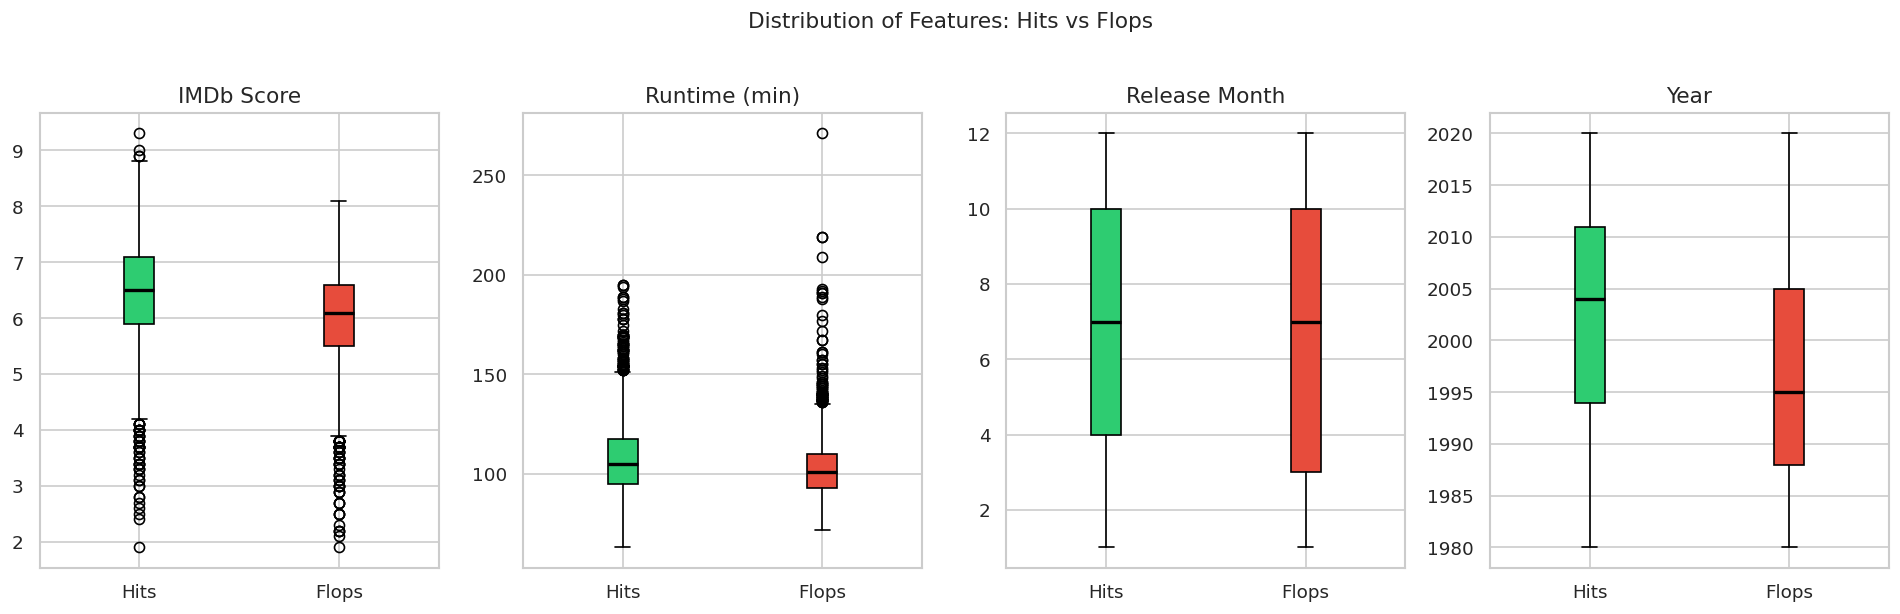

In [ ]:
# Visualise medians: hits vs flops side by side
features_plot = ['score','runtime','release_month','year']
labels = ['IMDb Score','Runtime (min)','Release Month','Year']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, feat, label in zip(axes, features_plot, labels):
    data = [hits_df[feat].dropna(), flops_df[feat].dropna()]
    bp = ax.boxplot(data, labels=['Hits','Flops'], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(label)

fig.suptitle('Distribution of Features: Hits vs Flops', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('boxplots_hit_vs_flop.png', bbox_inches='tight')
plt.show()

#Interpretation of Outputs
All major features have p < 0.05: Hits and flops differ significantly across most variables.

Votes & Gross Revenue: Hit movies have much higher median popularity and revenue.

Budget: Hits generally have larger budgets than flops.

Score: Hit movies tend to receive higher IMDb ratings.

Release Month: Although statistically significant, the actual difference is very small.

Boxplots: Hit movies generally show higher medians across score, runtime, and release year.
#Overall Insight

Hit and flop movies differ significantly in terms of popularity, financial performance, and audience ratings, making these variables strong predictors of movie success.

#STEP 10 — Multicollinearity Analysis using VIF

Measures how strongly each predictor variable is explained by the other predictors.

We avoid using variables like gross, ROI, and profit in VIF because movie success (is_hit / roi_class) is already derived from them, which can create target leakage and artificially inflate relationships.
Instead, we use independent predictors like budget, votes, score, runtime, and year to evaluate genuine predictor overlap and model stability.



Why is it used?

It helps identify whether predictors provide redundant information, which can reduce model stability and interpretability.

What are we doing?

We calculate VIF for independent predictors like score, votes, budget, runtime, and year to check whether they excessively overlap with each other.

In [ ]:
# ============================================================
# STEP 10 — Variance Inflation Factor (VIF) Analysis
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Select predictor variables
vif_features = df2[
    ['score', 'votes', 'budget', 'runtime', 'year']
].dropna()

# Add intercept term
X = add_constant(vif_features)

# Compute VIF
vif_data = pd.DataFrame()

vif_data['Feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Remove intercept row
vif_data = vif_data[vif_data['Feature'] != 'const']

# Sort by VIF
vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== Variance Inflation Factor (VIF) ===")
print(vif_data.to_string(index=False))

=== Variance Inflation Factor (VIF) ===
Feature      VIF
  votes 1.693082
 budget 1.510624
  score 1.507506
runtime 1.360258
   year 1.150606


#Interpretation of Outputs
All VIF values are close to 1.

The predictors show very low multicollinearity.

Votes (VIF ≈ 1.69): Votes has the highest overlap with other variables, but it is still within the safe range.

Budget, Score, Runtime, Year: These variables are relatively independent and statistically stable.

No VIF value exceeds 5.
There are no serious multicollinearity concerns in the selected predictors.

#Overall Insight

The selected predictor variables are stable and do not strongly overlap with each other, making them suitable for further predictive modeling.